In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Feature engineering 
df["ShotsDiff"]       = df["HomeShots"] - df["AwayShots"]
df["ShotsTargetDiff"] = df["HomeShotsTarget"] - df["AwayShotsTarget"]
df["CornersDiff"]     = df["HomeCorners"] - df["AwayCorners"]
df["GoalsDiff"]       = df["HomeGoals"] - df["AwayGoals"]

features = ["ShotsDiff", "ShotsTargetDiff", "CornersDiff",
            "HomeShots", "AwayShots", "HomeShotsTarget", "AwayShotsTarget"]

X = df[features]
y = df["Result"]   # H, D, A

# Split data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=1000, C=0.5, random_state=42)
model.fit(X_train, y_train)

# Evaluation 
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")
print("\nDetailed report:")
print(classification_report(y_test, y_pred))

Accuracy: 62.63%

Detailed report:
              precision    recall  f1-score   support

           A       0.61      0.75      0.67       127
           D       0.27      0.04      0.06        84
           H       0.65      0.83      0.73       169

    accuracy                           0.63       380
   macro avg       0.51      0.54      0.49       380
weighted avg       0.56      0.63      0.56       380



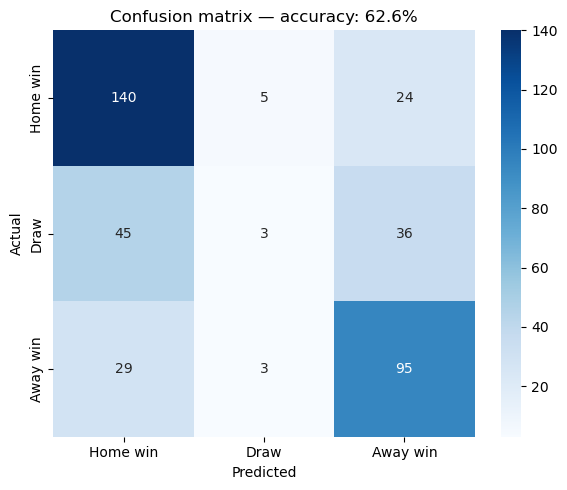

In [13]:
# Confusion matrix chart 
cm = confusion_matrix(y_test, y_pred, labels=["H", "D", "A"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Home win", "Draw", "Away win"],
            yticklabels=["Home win", "Draw", "Away win"])
plt.title(f"Confusion matrix — accuracy: {acc:.1%}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()

In [14]:
# Clean data for Power BI 
df["Predicted"] = model.predict(scaler.transform(df[features]))
df.to_csv("outputs/epl_clean_with_predictions.csv", index=False)
print("Exported! Open this file in Power BI.")

Exported! Open this file in Power BI.
